# Intro and initial EDA

https://www.sciencedirect.com/science/article/pii/S0957417424017895#sec3

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))


In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix 
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

from sklearn.decomposition import PCA

from data import DatasetLoader, utils


## Load Data

In [7]:
loader = DatasetLoader(raw_data_dir="../data/raw/", engineered_data_dir="../data/processed/")
non_spectral_df = loader.non_spectral()
grouped_spectral_df = loader.grouped_spectral()
master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)


## Precipitation

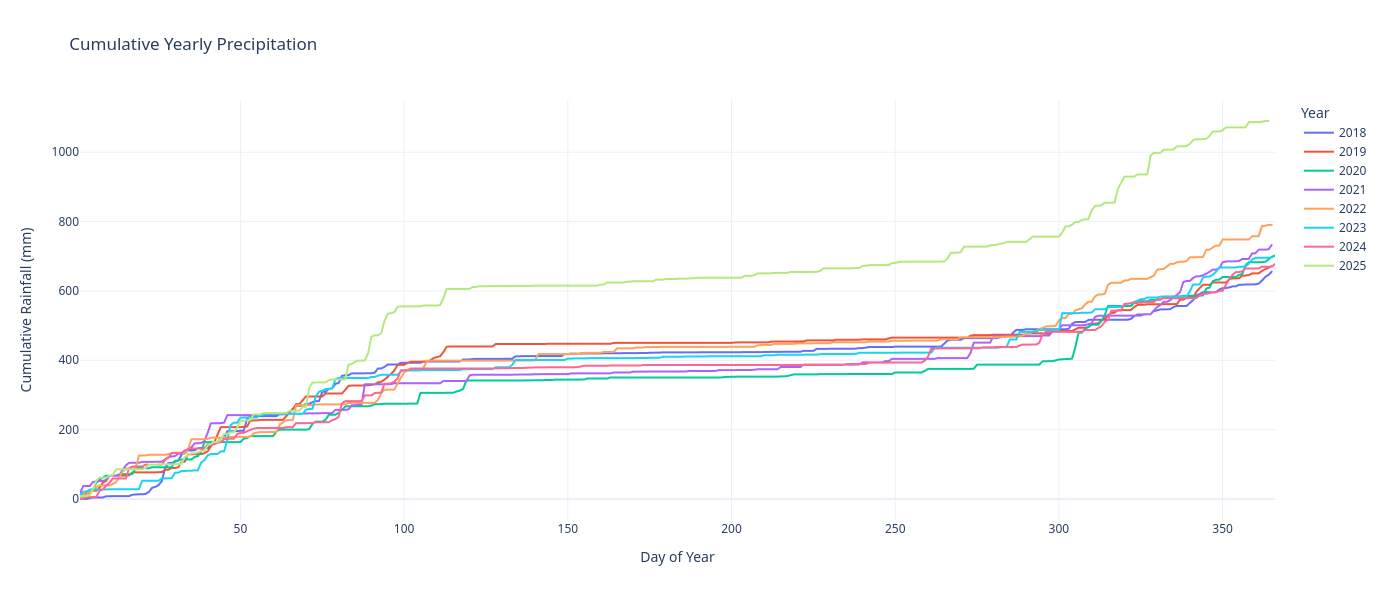

In [8]:
non_spectral_df["Year"] = non_spectral_df["Timestamp"].dt.year.astype(str) # Convert to string for discrete legend colors
non_spectral_df["doy"] = non_spectral_df["Timestamp"].dt.dayofyear

df_sorted = non_spectral_df.sort_values(["Year", "doy"])
df_sorted["cumulative_precipitation"] = df_sorted.groupby("Year")["precipitation"].cumsum()


fig = px.line(
    df_sorted, 
    x="doy", 
    y="cumulative_precipitation", 
    color="Year",
    title="Cumulative Yearly Precipitation",
    labels={"doy": "Day of Year", "cumulative_precipitation": "Cumulative Rainfall (mm)"},
    template="plotly_white",
    height=600
)

fig.update_layout(hovermode="x unified")

fig.show()

## Soil Temperature and Moisture

The ERA5 dataset provides us with 4 layers of soil temperature and volumetric water layers. 


| Band Name                     | Unit            | Description                                                                                                                                                                                                                                                                                                                |   |
|-------------------------------|-----------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---|
| soil_temperature_level_1      | K               | Temperature of the soil in layer 1 (0 - 7 cm) of the ECMWF Integrated Forecasting System. The surface is at 0 cm. Soil temperature is set at the middle of each layer, and heat transfer is calculated at the interfaces between them. It is assumed that there is no heat transfer out of the bottom of the lowest layer. |   |
| soil_temperature_level_2      | K               | Temperature of the soil in layer 2 (7-28 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                   |   |
| soil_temperature_level_3      | K               | Temperature of the soil in layer 3 (28-100 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                 |   |
| soil_temperature_level_4      | K               | Temperature of the soil in layer 4 (100-289 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                |   |
| volumetric_soil_water_layer_1 | Volume fraction | Volume of water in soil layer 1 (0 - 7 cm) of the ECMWF Integrated Forecasting System. The surface is at 0 cm. The volumetric soil water is associated with the soil texture (or classification), soil depth, and the underlying groundwater level.                                                                        |   |
| volumetric_soil_water_layer_2 | Volume fraction | Volume of water in soil layer 2 (7 -28 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                     |   |
| volumetric_soil_water_layer_3 | Volume fraction | Volume of water in soil layer 3 (28-100 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                    |   |
| volumetric_soil_water_layer_4 | Volume fraction | Volume of water in soil layer 4 (100-289 cm) of the ECMWF Integrated Forecasting System.                                                                                                                                                                                                                                   |   |

These measurements will play an integral role in providing us with information regarding the state of the crop under observation. A high soil temperature and a low moisture will naturally lead to the crop being highly stressed. We should take care when providing these measurements to a model however, since the shallow layers of the dataset will be highly correlated and not all models handle multicolinearity well.




### Soil Temperature Levels

#### Correlation

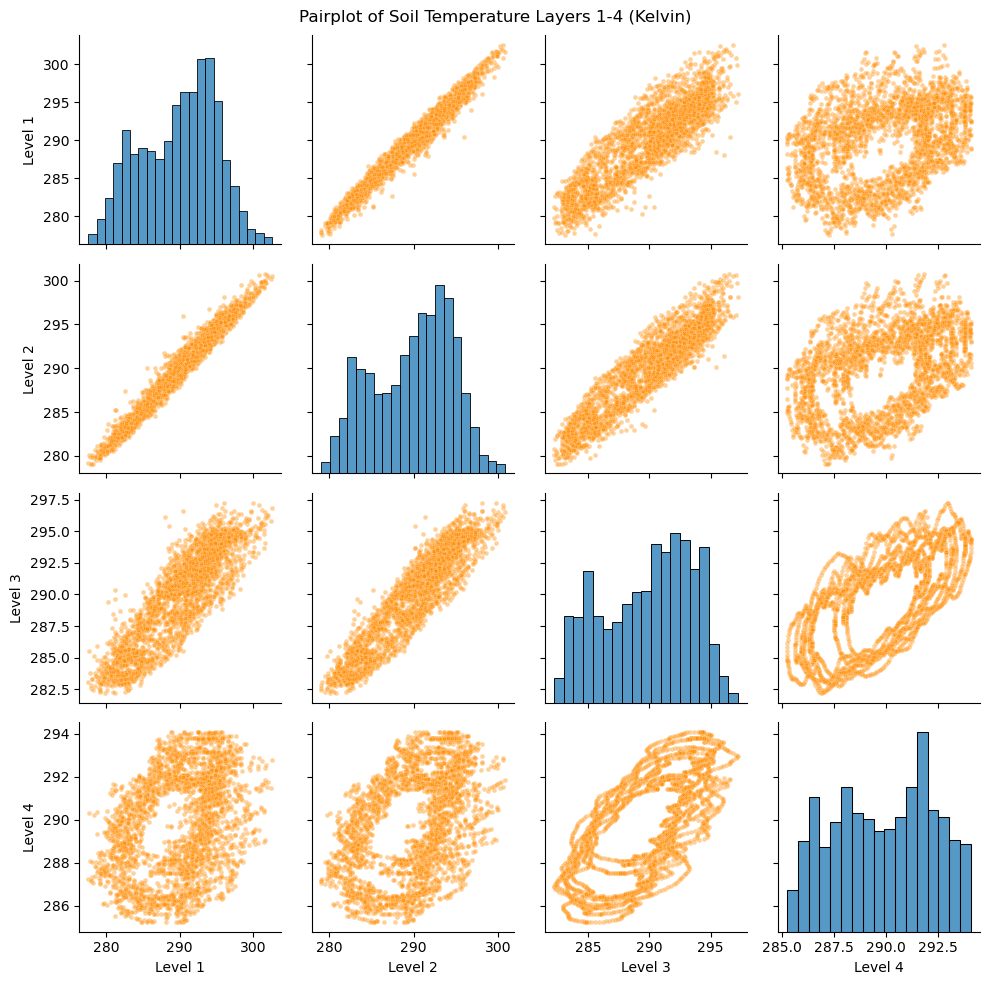

In [16]:
prefix = "soil_temperature_level"
layers = range(1, 5)
df_stl_plot = non_spectral_df[[f"{prefix}_{l}" for l in layers]]
df_stl_plot = df_stl_plot.rename(columns={ f"{prefix}_{l}" : f"Level {l}" for l in layers})

g = sns.pairplot(df_stl_plot, plot_kws={"color": "darkorange", "alpha": 0.4, "s":12})
g.fig.suptitle("Pairplot of Soil Temperature Layers 1-4 (Kelvin)")
g.fig.tight_layout()

plt.show()

It is immediately apparent that layers  1 to 3 are highly correlated, essentially mimicing a perfect linear relationship. We can further quantify this relatioship with a correlation matrix:

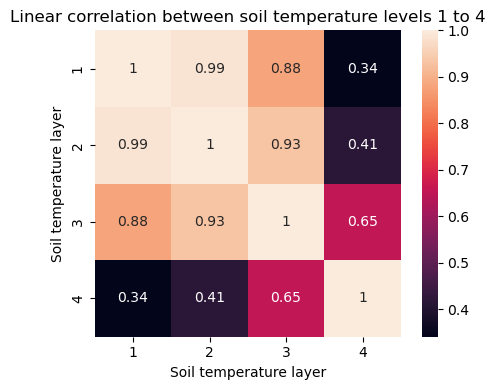

In [19]:
corr = non_spectral_df[[f"{prefix}_{l}" for l in layers]].corr()

plt.figure(figsize=(5,4))
plt.title("Linear correlation between soil temperature levels 1 to 4")

sns.heatmap(corr, xticklabels=layers, yticklabels=layers, annot=True, square=True)
plt.xlabel("Soil temperature layer")
plt.ylabel("Soil temperature layer")

plt.tight_layout()
plt.show()

Including these layers as-is will introduce quite a bit of redundancy in our data and will be easily accounted for by using dimensionality reduction methods like PCA.

#### Principal Component Analysis

Our first approach to PCA is a full fit on all 4 water layers. In essence, we are finding the principal directions of the soil temperature at different depths, i.e. the lower-dimensional projection of these data points in the direction of highest variance. This is done so in an effort to reduce the multicolinearity present within these features.

In [23]:
layers = range(1, 5)
stanscal = StandardScaler()

X = non_spectral_df[[f"{prefix}_{l}" for l in layers]]
X_pca_fit = stanscal.fit_transform(X)

In [24]:
pca = PCA()
pca.fit(X_pca_fit)

explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

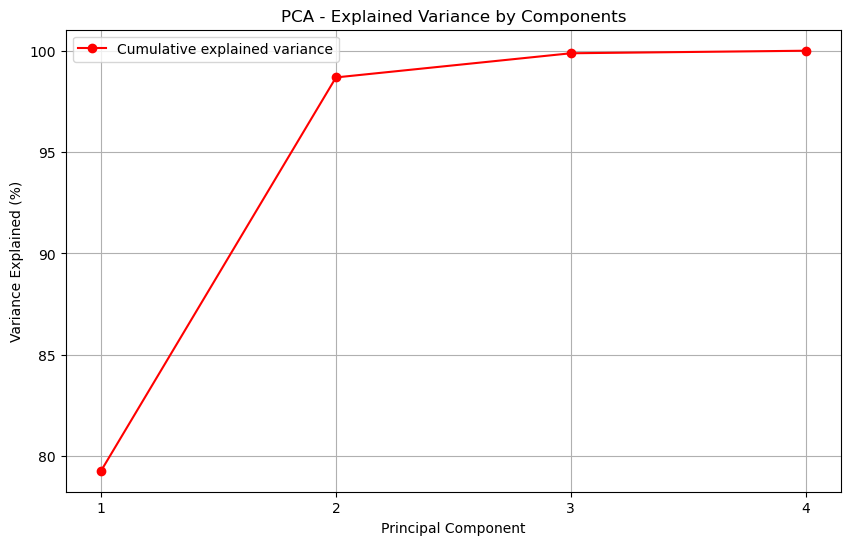

In [25]:
plt.figure(figsize=(10, 6))

components = np.arange(1, len(explained_variance) + 1)

plt.plot(components, cumulative_variance, marker='o', color='red', label='Cumulative explained variance')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA - Explained Variance by Components')
plt.xticks(components)
plt.legend()
plt.grid(True)

plt.show()

In [26]:
pca.components_

array([[ 0.52588674,  0.5428852 ,  0.55216453,  0.35189931],
       [-0.37201523, -0.28265153,  0.07053473,  0.8813272 ],
       [-0.54353841, -0.06187289,  0.77700072, -0.31146046],
       [-0.53815778,  0.78838792, -0.29395418,  0.04921003]])

The fact that 2 principal components explains almost 100% of the variance shows that these 4 predictors are actuality just in 2 dimensional space. Additionally, the loadings of the first principal component suggest that direction explains the overall soil warmth, while the loadings of the second suggest that direction explains the difference in temperature between the shallow levels and the deeper levels.

Something that still stands out in our correlation matrix is the fact that layers 1 through 3 are highly correlated ($\rho = 0.88 \ - \ 0.99$). This could suggest that they all pretty much explain the same thing and are highly redundant - and that "thing" could be summarised most concretely by projecting all 3 layers down to a single dimension. 

In [28]:
layers = range(1, 4)
stanscal = StandardScaler()

X = non_spectral_df[[f"{prefix}_{l}" for l in layers]]
X_pca_fit = stanscal.fit_transform(X)

In [29]:
pca = PCA()
pca.fit(X_pca_fit)

explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

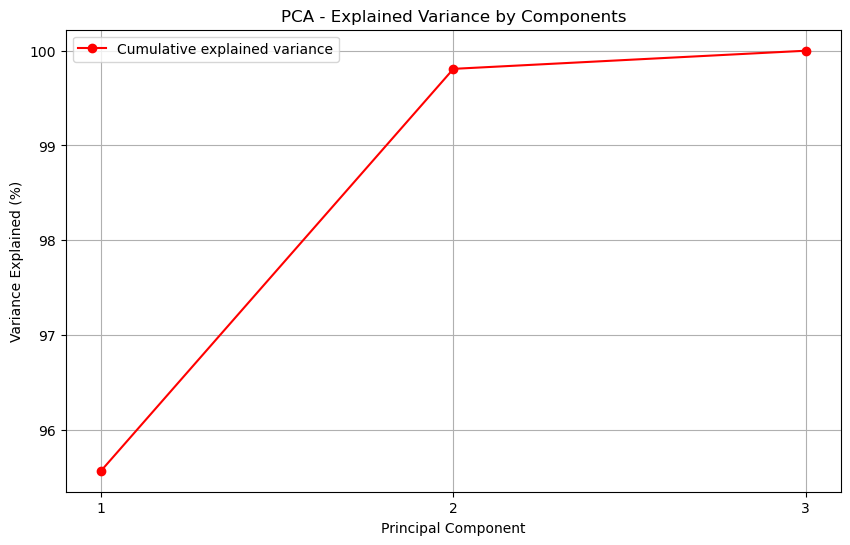

In [30]:
plt.figure(figsize=(10, 6))

components = np.arange(1, len(explained_variance) + 1)

plt.plot(components, cumulative_variance, marker='o', color='red', label='Cumulative explained variance')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA - Explained Variance by Components')
plt.xticks(components)
plt.legend()
plt.grid(True)

plt.show()

Indeed, one principal component explains $\sim 95\%$ of the common variation of the data in layers 1 to 3. This is a significant reduction in dimension and will almost certainly contribute to the elimination of multicolinearity. Keeping layer 4 as separate still allows for the analysis of the thermal behaviour of the deeper levels in a separate, uncorrelated feature.

### Volumetric Soil Water Layers

#### Correlation

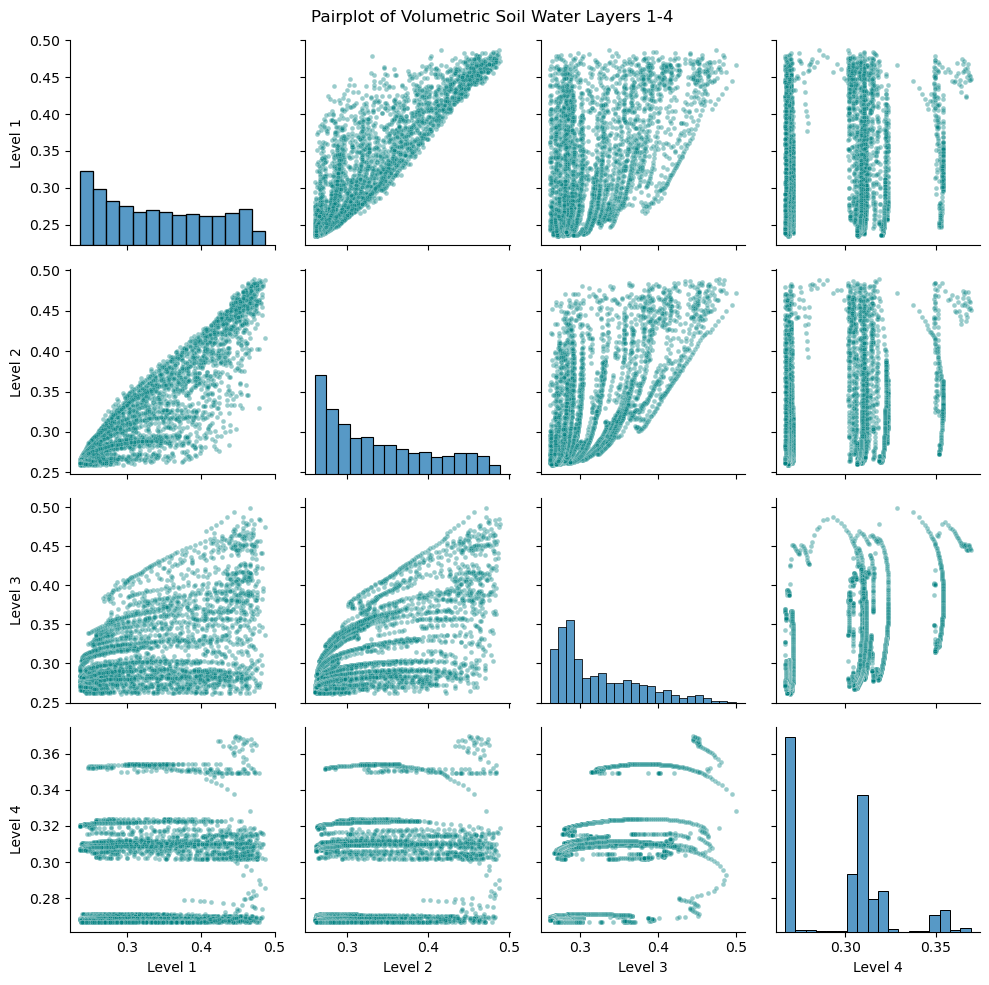

In [10]:
prefix = "volumetric_soil_water_layer"
layers = range(1, 5)
df_vwl_plot = non_spectral_df[[f"{prefix}_{l}" for l in layers]]
df_vwl_plot = df_vwl_plot.rename(columns={ f"{prefix}_{l}" : f"Level {l}" for l in layers})

 
g = sns.pairplot(df_vwl_plot, plot_kws={"color": "teal", "alpha": 0.4, "s":12})
g.fig.suptitle("Pairplot of Volumetric Soil Water Layers 1-4 ")
g.fig.tight_layout()

plt.show()

Interestingly, the soil moisture layers do not show such an immediately apparent linear relationship like soil temperature. One thing to note is the relationship between levels 1 and 2. A high moisture level in the shallow layer 1 almost never corresponds to a high moisture level in deeper layer 2. 

Similar to the soil temperature levels, it will be worth-while to consider PCA on possibly just the first two soil levels.

#### Principal Component Analysis

The reason we only consider the first two levels as stated above, is because of the possiblity of losing information when we project the deep layers to a lower dimension. This is because these layers inherently describe the long-term climate of the environment. They are remarkably stable throughout the year regardless of climate shocks and therefore carry the risk of shifting the principal components in an unfavourable direction (with respect to the more shallow layers).

In [144]:
prefix = "volumetric_soil_water_layer"
layers = range(1, 3)

stanscal = StandardScaler()

X = vw_df[[f"{prefix}_{l}" for l in layers]]
X_pca_fit = stanscal.fit_transform(X)

In [145]:
pca = PCA()
pca.fit(X_pca_fit)

explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

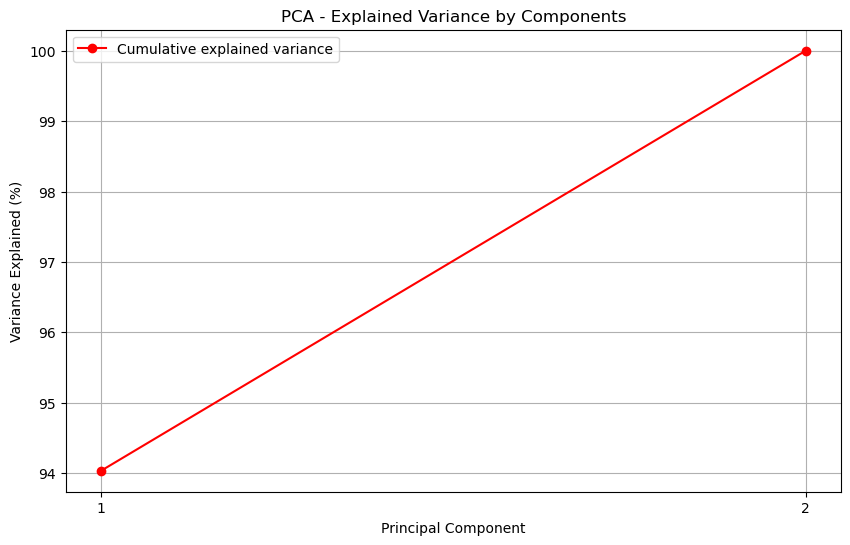

In [146]:
plt.figure(figsize=(10, 6))

components = np.arange(1, len(explained_variance) + 1)

plt.plot(components, cumulative_variance, marker='o', color='red', label='Cumulative explained variance')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA - Explained Variance by Components')
plt.xticks(components)
plt.legend()
plt.grid(True)

plt.show()

In [147]:
pca.components_

array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]])